In [1]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from scipy import stats

In [2]:
# H0 : diff Elo ไม่มีความสัมพันธ์เชิงเส้นกับ diff goal  (β = 0)
# H1 : diff Elo มีความสัมพันธ์เชิงเส้นกับ diff goal    (β ≠ 0)
alpha = 0.05

In [3]:
matches = pl.read_csv("../data/elo_matches.csv", try_parse_dates=True).with_columns(
    pl.col("Season").str.slice(0, 4).cast(pl.Int32).alias("year")
)

In [4]:
d = (
    matches.filter(
        pl.col("MatchDate") >= pl.col("MatchDate").min().over("Season") + pl.duration(days=28)
    )
    .drop_nulls(["elo_home", "elo_away"])
    .with_columns(
        diff_elo=pl.col("elo_home") - pl.col("elo_away"),
        diff_goal=pl.col("FullTimeHomeGoals") - pl.col("FullTimeAwayGoals"),
    )
)

In [5]:
d.head()

Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,elo_home,elo_away,exp_home,score_home,year,diff_elo,diff_goal
str,date,str,str,i64,i64,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i32,f64,i64
"""2000/01""",2000-09-16,"""Arsenal""","""Coventry""",2,1,"""H""",1,0,"""H""",18,6,13,2,8,4,5,13,1,2,0,0,1519.141023,1487.672188,0.635369,1.0,2000,31.468835,1
"""2000/01""",2000-09-16,"""Aston Villa""","""Bradford""",2,0,"""H""",1,0,"""H""",12,8,7,4,5,6,8,12,0,2,0,0,1499.415305,1485.583781,0.61154,1.0,2000,13.831524,2
"""2000/01""",2000-09-16,"""Charlton""","""Tottenham""",1,0,"""H""",1,0,"""H""",9,10,5,5,7,5,8,10,0,0,0,0,1487.780968,1516.677042,0.551772,1.0,2000,-28.896074,1
"""2000/01""",2000-09-16,"""Everton""","""Man United""",1,3,"""A""",0,3,"""A""",6,17,4,9,6,5,10,11,4,1,0,0,1505.207155,1542.933734,0.539169,0.0,2000,-37.726579,-2
"""2000/01""",2000-09-16,"""Leeds""","""Ipswich""",1,2,"""A""",1,1,"""D""",11,12,6,7,6,3,12,19,1,3,0,0,1512.508303,1475.455403,0.642783,0.0,2000,37.0529,-1


In [6]:
print(d.shape)
print(matches["Season"].unique().sort().to_list())

(8469, 29)
['2000/01', '2001/02', '2002/03', '2003/04', '2004/05', '2005/06', '2006/07', '2007/08', '2008/09', '2009/10', '2010/11', '2011/12', '2012/13', '2013/14', '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25']


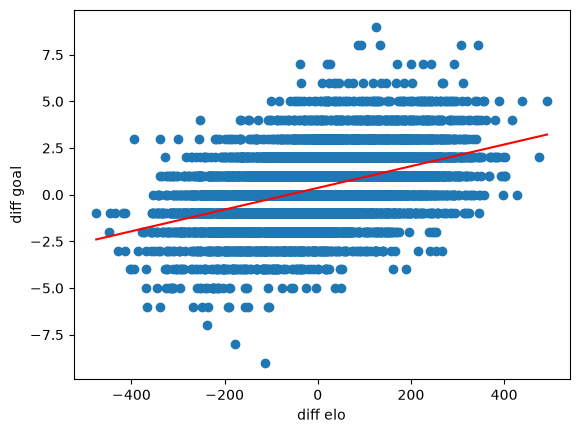

In [7]:
slope, intercept = np.polyfit(d["diff_elo"], d["diff_goal"], 1)
xs = np.linspace(d["diff_elo"].min(), d["diff_elo"].max(), 100)
plt.plot(xs, slope * xs + intercept, color="red")
plt.scatter(d["diff_elo"], d["diff_goal"])
plt.xlabel("diff elo")
plt.ylabel("diff goal")
plt.show()

In [8]:
res = stats.linregress(d["diff_elo"], d["diff_goal"])

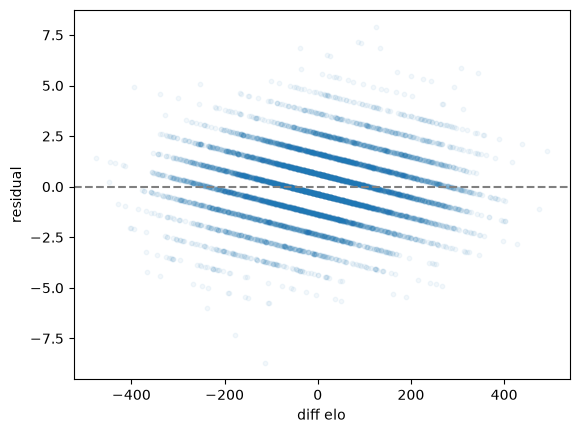

In [9]:
pred = res.slope * d["diff_elo"] + res.intercept
resid = d["diff_goal"] - pred

plt.scatter(d["diff_elo"], resid, alpha=alpha, s=10)
plt.axhline(0, color="gray", ls="--")
plt.xlabel("diff elo")
plt.ylabel("residual")
plt.show()

In [10]:
r, p = stats.pearsonr(d["diff_elo"], d["diff_goal"])
rho, p_s = stats.spearmanr(d["diff_elo"], d["diff_goal"])
print(f"Pearson r={r:.3f}, p={p:.3g} | Spearman rho={rho:.3f}, p={p_s:.3g}")

Pearson r=0.441, p=0 | Spearman rho=0.429, p=0


In [11]:
g = d.filter(pl.col("diff_elo").abs() < 25)["diff_goal"].to_numpy()
t, p = stats.ttest_1samp(g, 0)
print(len(g), g.mean(), f"t={t:.2f}, p={p:.3g}")

1406 0.3940256045519203 t=9.20, p=1.2e-19


In [12]:
if p < alpha:
    print(f"สรุปผล: ปฏิเสธ H0 (p = {p:.3g} < {alpha}) - diff Elo มีความสัมพันธ์เชิงเส้นกับ diff goal")
else:
    print(
        f"สรุปผล: ไม่สามารถปฏิเสธ H0 (p = {p:.3g} ≥ {alpha}) - ยังไม่พบหลักฐานว่า diff Elo มีความสัมพันธ์เชิงเส้นกับ diff goal"
    )

สรุปผล: ปฏิเสธ H0 (p = 1.2e-19 < 0.05) - diff Elo มีความสัมพันธ์เชิงเส้นกับ diff goal
